# BASS × NBD-Dirichlet 融合モデル：プロモーション効果の判定

新商品（飲料カテゴリ）発売時の **試用（Trial）** と **リピート購買（Repeat）** を統合モデル化し、
プロモーション実施の効果を **ベイズ推定（Turing.jl）** で定量評価する。

## データ

- **POS データ**: 100本ノック POSデータ（飲料カテゴリ 0710、148 週間）
- **ブランド**: 果汁・清涼飲料 / お茶飲料 / コーヒー飲料 / 機能性飲料 / 炭酸飲料 / 水 / その他（計 7 ブランド）
- **消費者**: 3,325 人
- **プロモ判定**: 週次新規試用者数の上位四分位（P75 超）をプロモーション活動週とみなす

---

## モデル構造

| コンポーネント | 数理モデル | 推定量 |
|---|---|---|
| 試用拡散 | 拡張 BASS（離散差分 + MTK シミュレーション） | $p,\, q,\, M,\, \gamma_p$ |
| リピート購買 | 集約 NBD | $K_r,\, \mu_r,\, \delta_r$ |
| ブランド選択 | Dirichlet-Multinomial | $S,\, \mathbf{p}$ |

### 拡張 BASS（試用）

$$\lambda_t^{\text{trial}} = \bigl(p \cdot e^{\gamma_p \cdot \text{Promo}(t)} + q \cdot N(t\!-\!1)/M\bigr)\,(M - N(t\!-\!1))$$

### 集約 NBD（リピート）

$$n_{\text{repeat}}[t] \sim \operatorname{NegBin}\!\left(N(t\!-\!1)\cdot K_r,\; \frac{K_r}{K_r + \mu_r \cdot e^{\delta_r \cdot \text{Promo}(t)}}\right)$$

### 判定基準

- $P(\gamma_p > 0 \mid \text{data}) > 0.95$ → 試用促進効果あり（有意）
- $P(\delta_r > 0 \mid \text{data}) > 0.95$ → リピート促進効果あり（有意）
- 効果量の目安：$e^{\gamma_p}$（試用の倍率）、$e^{\delta_r}$（リピート率の倍率）

In [35]:
# 初回実行時のみ（インストール済みならスキップ）
import Pkg
Pkg.add([
    "ModelingToolkit", "DifferentialEquations",
    "Turing", "Distributions", "MCMCChains",
    "StatsPlots", "DataFrames", "SpecialFunctions",
    "CSV"
])

   Resolving package versions...
     Project No packages added to or removed from `C:\Users\kimse\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\kimse\.julia\environments\v1.12\Manifest.toml`


In [36]:
using ModelingToolkit
using ModelingToolkit: t_nounits as t, D_nounits as D
using DifferentialEquations
using Turing
using Distributions
using StatsPlots
using DataFrames
using MCMCChains
using SpecialFunctions
using CSV
using Random
using Statistics
using Printf

Random.seed!(2024)
println("Julia version: ", VERSION)

Julia version: 1.12.5


In [37]:
ENV["GKS_ENCODING"] = "utf8"
gr(fontfamily="PlemolJP-Text")
default(
    fontfamily  = "PlemolJP-Text",
    guidefontsize  = 11,
    tickfontsize   = 9,
    legendfontsize = 9,
    margin = 5Plots.mm,
)

---
## 1. POSデータの読み込みと可視化

前処理済み CSV を読み込む。

| ファイル | 内容 |
|---|---|
| `beverage_weekly.csv` | 週次の新規試用者数・リピート購買数・プロモフラグ |
| `beverage_brand_matrix.csv` | 消費者 × ブランド別購買回数行列（Dirichlet 用）|

In [38]:
# ---- データ読み込み ----
df_weekly = CSV.read("beverage_weekly.csv", DataFrame)
df_brand  = CSV.read("beverage_brand_matrix.csv", DataFrame)

println("=== 週次データ ===")
println("  期間: $(nrow(df_weekly)) 週")
println("  累積試用者数: $(df_weekly.cum_trial[end])")
println("  総リピート購買: $(sum(df_weekly.n_repeat))")
println("  プロモ週数: $(sum(df_weekly.promo)) / $(nrow(df_weekly))")

println("\n=== ブランド別データ ===")
println("  消費者数: $(nrow(df_brand))")
brand_cols = names(df_brand)[3:end]   # skip customer_id, n_cat
for col in brand_cols
    n_buyers = sum(df_brand[!, col] .> 0)
    total    = sum(df_brand[!, col])
    @printf("  %-24s  購買者=%4d  購買数=%5d  シェア=%.1f%%\n",
            col, n_buyers, total, total / sum(df_brand.n_cat) * 100)
end

=== 週次データ ===
  期間: 148 週
  累積試用者数: 3466
  総リピート購買: 4735
  プロモ週数: 37 / 148

=== ブランド別データ ===
  消費者数: 3325
  071001_果汁・清涼飲料     購買者=1183  購買数= 2139  シェア=26.1%
  071002_炭酸飲料           購買者= 488  購買数=  797  シェア=9.7%
  071003_機能性飲料ドリンク  購買者= 797  購買数= 1351  シェア=16.5%
  071004_コーヒー飲料       購買者= 857  購買数= 1513  シェア=18.4%
  071005_お茶飲料           購買者= 974  購買数= 1838  シェア=22.4%
  071006_水                 購買者= 281  購買数=  483  シェア=5.9%
  071007_その他飲料         購買者=  56  購買数=   88  シェア=1.1%


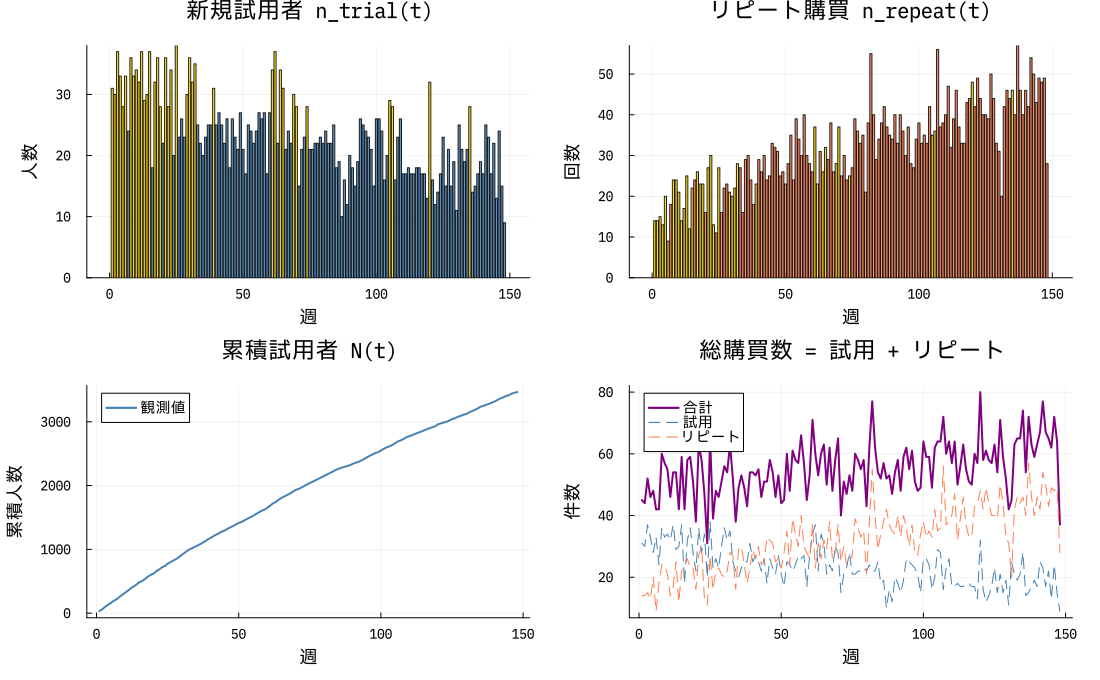

In [39]:
T_PERIODS = nrow(df_weekly)
weeks     = df_weekly.week
n_trial_obs  = df_weekly.n_trial
n_repeat_obs = df_weekly.n_repeat
promo_vec    = df_weekly.promo
N_cum_obs    = df_weekly.cum_trial

# 棒グラフの色
color_trial  = ifelse.(promo_vec .== 1, :gold, :steelblue)
color_repeat = ifelse.(promo_vec .== 1, :gold, :coral)

p1 = bar(weeks, n_trial_obs;
    color=color_trial, alpha=0.85, label="",
    title="新規試用者 n_trial(t)",
    xlabel="週", ylabel="人数")

p2 = bar(weeks, n_repeat_obs;
    color=color_repeat, alpha=0.85, label="",
    title="リピート購買 n_repeat(t)",
    xlabel="週", ylabel="回数")

p3 = plot(weeks, N_cum_obs;
    lw=2, color=:steelblue, label="観測値",
    title="累積試用者 N(t)",
    xlabel="週", ylabel="累積人数")

p4 = plot(weeks, n_trial_obs .+ n_repeat_obs;
    lw=2, color=:purple, label="合計",
    title="総購買数 = 試用 + リピート",
    xlabel="週", ylabel="件数")
plot!(p4, weeks, n_trial_obs;  lw=1, ls=:dash, color=:steelblue, label="試用")
plot!(p4, weeks, n_repeat_obs; lw=1, ls=:dash, color=:coral,     label="リピート")

plot(p1, p2, p3, p4; layout=(2,2), size=(1100, 680))

---
## 2. ModelingToolkit による拡張 BASS モデルのシミュレーション

プロモーション指標関数 $\text{Promo}(t)$ を `@register_symbolic` で ODE に組み込み、
$\gamma_p$ の大きさが普及曲線に与える影響を視覚的に確認する。

$$\frac{dN}{dt} = \bigl(p \cdot e^{\gamma_p \cdot \text{Promo}(t)} + q \cdot N/M\bigr)\,(M - N)$$

In [40]:
# ---- プロモーション指標（実データの promo_vec を補間）----
const PROMO_DATA = Float64.(promo_vec)

function promo_signal(t_val::Real)
    idx = clamp(round(Int, t_val), 1, length(PROMO_DATA))
    return PROMO_DATA[idx]
end
@register_symbolic promo_signal(t)

# ---- 拡張 BASS ODESystem ----
@parameters p_bass q_bass M_bass gp_param
@variables N_bass(t) n_bass(t)

eqs_bass_promo = [
    D(N_bass) ~ (p_bass * exp(gp_param * promo_signal(t)) + q_bass * N_bass / M_bass) *
                 (M_bass - N_bass),
    n_bass    ~ (p_bass * exp(gp_param * promo_signal(t)) + q_bass * N_bass / M_bass) *
                 (M_bass - N_bass)
]

@named bass_promo_sys = ODESystem(eqs_bass_promo, t)
sys_promo = mtkcompile(bass_promo_sys)

println("ModelingToolkit 拡張 BASS モデル定義完了")

ModelingToolkit 拡張 BASS モデル定義完了


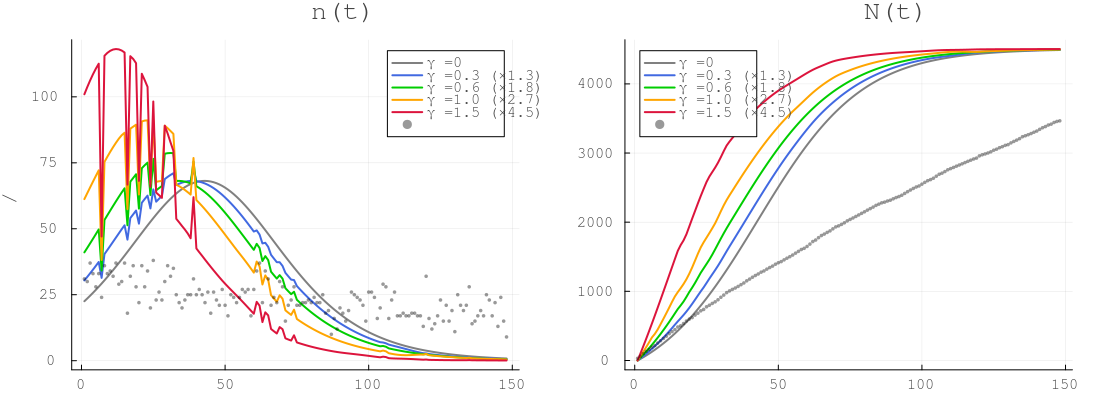

GKS: glyph missing from current font: 36913
GKS: invalid bitmap size
GKS: glyph missing from current font: 20154
GKS: glyph missing from current font: 25968
GKS: glyph missing from current font: 36913
GKS: glyph missing from current font: 20154
GKS: glyph missing from current font: 25968
GKS: glyph missing from current font: 36913
GKS: glyph missing from current font: 26032
GKS: glyph missing from current font: 35215
GKS: glyph missing from current font: 35430
GKS: glyph missing from current font: 29992
GKS: glyph missing from current font: 32773
GKS: glyph missing from current font: 26032
GKS: glyph missing from current font: 35215
GKS: glyph missing from current font: 35430
GKS: glyph missing from current font: 29992
GKS: glyph missing from current font: 32773
GKS: glyph missing from current font: 8346
GKS: glyph missing from current font: 65288
GKS: glyph missing from current font: 21177
GKS: glyph missing from current font: 26524
GKS: glyph missing from current font: 12394
GKS: gly

In [65]:
default(
    fontfamily  = "PlemolJP",
    guidefontsize  = 10,
    tickfontsize   = 8,
    legendfontsize = 8,
    margin = 5Plots.mm,
)

# ---- γp 感度分析 ----
M_est_rough = Float64(N_cum_obs[end]) * 1.3   # 大まかな市場ポテンシャル推定
tspan_sim   = (1.0, Float64(T_PERIODS))
gp_vals     = [0.0, 0.3, 0.6, 1.0, 1.5]
colors_gp   = [:gray, :royalblue, :green3, :orange, :crimson]

fig1 = plot(layout=(1,2), size=(1100, 420),
            title=["新規試用者 n(t)" "累積試用者 N(t)"])

for (k, gp) in enumerate(gp_vals)
    prob_k = ODEProblem(sys_promo,
        Dict(N_bass => 0.0, p_bass => 0.005, q_bass => 0.05,
             M_bass => M_est_rough, gp_param => gp),
        tspan_sim)
    sol_k = solve(prob_k, Tsit5(); saveat=1.0)

    lbl = gp == 0.0 ? "γₚ=0（効果なし）" : "γₚ=$gp (×$(round(exp(gp), digits=1)))"
    plot!(fig1[1], sol_k.t, sol_k[n_bass]; lw=2, color=colors_gp[k], label=lbl)
    plot!(fig1[2], sol_k.t, sol_k[N_bass]; lw=2, color=colors_gp[k], label=lbl)
end

# 実測値を重ねて表示
scatter!(fig1[1], weeks, n_trial_obs; ms=2, alpha=0.4, color=:black, label="実測")
scatter!(fig1[2], weeks, N_cum_obs;   ms=2, alpha=0.4, color=:black, label="実測")

xlabel!(fig1[1], "週"); ylabel!(fig1[1], "人数/週")
xlabel!(fig1[2], "週"); ylabel!(fig1[2], "累積人数")
display(fig1)

---
## 3. Turing.jl ベイズモデル定義

### フルモデル（プロモーション効果パラメータあり）

| パラメータ | 事前分布 | 根拠 |
|---|---|---|
| `p_v` | $\text{TruncNormal}(0.01, 0.01)$ | BASSの典型的イノベーション係数 |
| `q_v` | $\text{TruncNormal}(0.05, 0.05)$ | 長期拡散データ向け |
| `M_v` | $\text{TruncNormal}(\hat{M}, 1000)$ | 累積試用者数 ×1.3 を中心 |
| `gamma_p` | $\mathcal{N}(0, 1.0)$ | 効果ゼロを中心に設定 |
| `sigma_t` | $\text{Exp}(5)$ | 試用の観測ノイズ |
| `K_r` | $\text{TruncNormal}(0.8, 0.5)$ | NBD 典型値 |
| `mu_r` | $\text{TruncNormal}(0.5, 0.3)$ | 購買者あたり週次リピート率 |
| `delta_r` | $\mathcal{N}(0, 1.0)$ | 効果ゼロを中心に設定 |

In [ ]:
# ==== フルモデル（γp, δr 自由）====
@model function bass_nbd_model(
    n_trial  :: Vector{Int},
    n_repeat :: Vector{Int},
    promo    :: Vector{Int},
    M_lo     :: Float64,
    M_prior  :: Float64
)
    T = length(n_trial)

    # ---- 事前分布 ----
    p_v     ~ truncated(Normal(0.010, 0.010), 1e-5, 0.3)
    q_v     ~ truncated(Normal(0.050, 0.050), 1e-5, 1.0)
    M_v     ~ truncated(Normal(M_prior, 1000.0), M_lo, M_prior * 3.0)
    gamma_p ~ Normal(0.0, 1.0)           # 試用プロモーション効果
    sigma_t ~ Exponential(5.0)            # 試用ノイズ
    K_r     ~ truncated(Normal(0.80, 0.50), 0.05, 10.0)
    mu_r    ~ truncated(Normal(0.50, 0.30), 0.01, 5.0)
    delta_r ~ Normal(0.0, 1.0)           # リピートプロモーション効果

    # ---- BASS 期待軌跡（離散差分）----
    N_cum      = zero(p_v)
    lambda_vec = Vector{typeof(p_v)}(undef, T)
    N_prev_vec = Vector{typeof(p_v)}(undef, T)

    for t in 1:T
        N_prev_vec[t] = N_cum
        raw_lam = (p_v * exp(gamma_p * promo[t]) + q_v * N_cum / M_v) *
                  (M_v - N_cum)
        lam_t = raw_lam > 0 ? raw_lam : zero(raw_lam)
        lambda_vec[t] = lam_t
        N_cum = N_cum + lam_t
    end

    # ---- 試用尤度 ----
    for t in 1:T
        mu_t = lambda_vec[t] + 1e-3 * one(p_v)
        n_trial[t] ~ Normal(mu_t, sigma_t + sqrt(mu_t))
    end

    # ---- リピート尤度（集約 NBD）----
    for t in 2:T
        N_prev = N_prev_vec[t]
        if N_prev > 0.5
            mu_r_t = mu_r * exp(delta_r * promo[t])
            p_nb   = K_r / (K_r + mu_r_t)
            r_nb   = N_prev * K_r
            n_repeat[t] ~ NegativeBinomial(r_nb, p_nb; check_args=false)
        end
    end
end

println("フルモデル定義完了（パラメータ数: 8）")

In [ ]:
# ==== 制約モデル（γp = δr = 0：プロモ効果なし）====
@model function bass_nbd_model_null(
    n_trial  :: Vector{Int},
    n_repeat :: Vector{Int},
    M_lo     :: Float64,
    M_prior  :: Float64
)
    T = length(n_trial)

    p_v     ~ truncated(Normal(0.010, 0.010), 1e-5, 0.3)
    q_v     ~ truncated(Normal(0.050, 0.050), 1e-5, 1.0)
    M_v     ~ truncated(Normal(M_prior, 1000.0), M_lo, M_prior * 3.0)
    sigma_t ~ Exponential(5.0)
    K_r     ~ truncated(Normal(0.80, 0.50), 0.05, 10.0)
    mu_r    ~ truncated(Normal(0.50, 0.30), 0.01, 5.0)

    N_cum      = zero(p_v)
    lambda_vec = Vector{typeof(p_v)}(undef, T)
    N_prev_vec = Vector{typeof(p_v)}(undef, T)

    for t in 1:T
        N_prev_vec[t] = N_cum
        raw_lam = (p_v + q_v * N_cum / M_v) * (M_v - N_cum)
        lam_t = raw_lam > 0 ? raw_lam : zero(raw_lam)
        lambda_vec[t] = lam_t
        N_cum = N_cum + lam_t
    end

    for t in 1:T
        mu_t = lambda_vec[t] + 1e-3 * one(p_v)
        n_trial[t] ~ Normal(mu_t, sigma_t + sqrt(mu_t))
    end

    for t in 2:T
        N_prev = N_prev_vec[t]
        if N_prev > 0.5
            p_nb = K_r / (K_r + mu_r)
            r_nb = N_prev * K_r
            n_repeat[t] ~ NegativeBinomial(r_nb, p_nb; check_args=false)
        end
    end
end

println("制約モデル定義完了（パラメータ数: 6）")

---
## 4. MCMC サンプリング

- **サンプラー**: NUTS（No-U-Turn Sampler、δ = 0.65）
- **ウォームアップ**: 500 サンプル
- **本サンプル**: 1,000 × 2 チェーン = 計 2,000 サンプル

In [ ]:
# ---- M の事前分布パラメータ ----
M_LO    = Float64(N_cum_obs[end]) * 1.05
M_PRIOR = Float64(N_cum_obs[end]) * 1.30

@printf("M の事前分布: 下限=%.0f  中心=%.0f\n", M_LO, M_PRIOR)

# ---- フルモデル MCMC ----
model_full = bass_nbd_model(
    Int.(n_trial_obs), Int.(n_repeat_obs), Int.(promo_vec), M_LO, M_PRIOR
)

println("\nフルモデル サンプリング開始...")
@time chain_full = sample(
    model_full,
    NUTS(500, 0.65),
    MCMCSerial(), 1000, 2;
    progress = true
)
println("完了")

In [ ]:
# ---- 制約モデル MCMC ----
model_null = bass_nbd_model_null(
    Int.(n_trial_obs), Int.(n_repeat_obs), M_LO, M_PRIOR
)

println("制約モデル サンプリング開始...")
@time chain_null = sample(
    model_null,
    NUTS(500, 0.65),
    MCMCSerial(), 1000, 2;
    progress = true
)
println("完了")

---
## 5. 収束診断

- $\hat{R} < 1.05$ なら収束
- 有効サンプルサイズ (ESS) $> 400$ が目安

In [ ]:
println("=== フルモデル 収束診断 ===")
summarize(chain_full)

In [ ]:
plot(chain_full[["p_v","q_v","M_v","gamma_p","sigma_t","K_r","mu_r","delta_r"]];
    left_margin = 5Plots.mm, bottom_margin = 3Plots.mm,
    size = (1000, 850), legend = false)

---
## 6. プロモーション効果の分析

### 判定ロジック

| 条件 | 判定 |
|---|---|
| 95% CI の下限 $> 0$ | **有意な促進効果あり** |
| $P(\text{param} > 0) > 0.90$ | 効果の傾向あり |
| 95% CI が 0 を含む & $P > 0.90$ 未満 | 効果は不明確 |

In [ ]:
# ---- 事後サンプルの取得 ----
gamma_p_samp = vec(chain_full[:gamma_p])
delta_r_samp = vec(chain_full[:delta_r])

prob_gp = mean(gamma_p_samp .> 0)
prob_dr = mean(delta_r_samp .> 0)
ci_gp   = quantile(gamma_p_samp, [0.025, 0.975])
ci_dr   = quantile(delta_r_samp, [0.025, 0.975])

# γp 事後分布
plt_gp = density(gamma_p_samp;
    lw=2, color=:steelblue, fill=(0, 0.2, :steelblue), label="事後分布",
    xlabel="γₚ（試用プロモーション効果）", ylabel="確率密度",
    title=@sprintf("γₚ 事後分布  P(γₚ>0)=%.3f", prob_gp))
vline!(plt_gp, [0.0]; lw=2, ls=:dash, color=:gray, label="0 (効果なし)")
vspan!(plt_gp, [ci_gp[1], ci_gp[2]]; alpha=0.15, color=:steelblue, label="95% CI")

# δr 事後分布
plt_dr = density(delta_r_samp;
    lw=2, color=:orange, fill=(0, 0.2, :orange), label="事後分布",
    xlabel="δᵣ（リピートプロモーション効果）", ylabel="確率密度",
    title=@sprintf("δᵣ 事後分布  P(δᵣ>0)=%.3f", prob_dr))
vline!(plt_dr, [0.0]; lw=2, ls=:dash, color=:gray, label="0 (効果なし)")
vspan!(plt_dr, [ci_dr[1], ci_dr[2]]; alpha=0.15, color=:orange, label="95% CI")

plot(plt_gp, plt_dr; layout=(1,2), size=(950, 380))

In [ ]:
# ---- 効果量の倍率（exp スケール）----
exp_gp = exp.(gamma_p_samp)
exp_dr = exp.(delta_r_samp)

plt_egp = density(exp_gp;
    lw=2, color=:steelblue, fill=(0, 0.2, :steelblue), label="事後分布",
    xlabel="exp(γₚ)：試用の倍率",
    title="プロモ期間の試用倍率")
vline!(plt_egp, [1.0]; lw=2, ls=:dash, color=:gray, label="1 (効果なし)")

plt_edr = density(exp_dr;
    lw=2, color=:orange, fill=(0, 0.2, :orange), label="事後分布",
    xlabel="exp(δᵣ)：リピート率の倍率",
    title="プロモ期間のリピート倍率")
vline!(plt_edr, [1.0]; lw=2, ls=:dash, color=:gray, label="1 (効果なし)")

plot(plt_egp, plt_edr; layout=(1,2), size=(950, 380))

In [ ]:
# ---- プロモーション効果の判定 ----
function judge(prob_pos::Float64, ci_lo::Float64, ci_hi::Float64)::String
    ci_lo > 0     && return "有意な促進効果あり"
    ci_hi < 0     && return "抑制効果の可能性"
    prob_pos > 0.90 && return "効果の傾向あり"
    return "効果は不明確"
end

df_judgment = DataFrame(
    効果        = ["試用促進 (γₚ)", "リピート促進 (δᵣ)"],
    事後平均    = round.([mean(gamma_p_samp), mean(delta_r_samp)], digits=3),
    CI95_下限   = round.([ci_gp[1], ci_dr[1]], digits=3),
    CI95_上限   = round.([ci_gp[2], ci_dr[2]], digits=3),
    P_効果あり  = round.([prob_gp, prob_dr], digits=3),
    倍率_推定   = round.(exp.([mean(gamma_p_samp), mean(delta_r_samp)]), digits=2),
    判定        = [judge(prob_gp, ci_gp[1], ci_gp[2]),
                   judge(prob_dr, ci_dr[1], ci_dr[2])]
)
println("=== プロモーション効果 判定結果 ===\n")
display(df_judgment)

# ---- 全パラメータ回収テーブル ----
function pstat(chain, sym)
    v = vec(chain[sym])
    (mean=mean(v), lo=quantile(v,0.025), hi=quantile(v,0.975))
end

param_names  = ["p_v","q_v","M_v","gamma_p","sigma_t","K_r","mu_r","delta_r"]
labels_jp    = ["p（イノベーション）","q（イミテーション）","M（ポテンシャル）",
                "γₚ（試用効果）","σt（ノイズ）",
                "K_r（NBD集約）","μ_r（リピート率）","δᵣ（リピート効果）"]
df_all = DataFrame(
    パラメータ = labels_jp,
    事後平均   = [round(pstat(chain_full, Symbol(s)).mean, digits=4) for s in param_names],
    CI95_下限  = [round(pstat(chain_full, Symbol(s)).lo,   digits=4) for s in param_names],
    CI95_上限  = [round(pstat(chain_full, Symbol(s)).hi,   digits=4) for s in param_names],
)
println("\n=== 全パラメータ推定結果 ===\n")
display(df_all)

---
## 7. 事後予測チェック

事後サンプルから BASS 期待軌跡を再現し、観測値との一致を確認する。
制約モデル（プロモ効果なし）との比較も併せて示す。

In [ ]:
# ---- 事後サンプルから予測バンド ----
p_samp   = vec(chain_full[:p_v])
q_samp   = vec(chain_full[:q_v])
M_samp   = vec(chain_full[:M_v])
gp_samp  = vec(chain_full[:gamma_p])
Kr_samp  = vec(chain_full[:K_r])
mur_samp = vec(chain_full[:mu_r])
dr_samp  = vec(chain_full[:delta_r])

n_post = length(p_samp)
T = T_PERIODS
trial_pred  = zeros(n_post, T)
repeat_pred = zeros(n_post, T)

for i in 1:n_post
    Nc = 0.0
    for tt in 1:T
        lam = (p_samp[i] * exp(gp_samp[i] * promo_vec[tt]) +
               q_samp[i] * Nc / M_samp[i]) * max(M_samp[i] - Nc, 0.0)
        lam = max(lam, 0.001)
        trial_pred[i, tt] = lam
        if Nc > 0.5
            repeat_pred[i, tt] = Nc * mur_samp[i] * exp(dr_samp[i] * promo_vec[tt])
        end
        Nc += lam
    end
end

t_med = [median(trial_pred[:, j]) for j in 1:T]
t_lo  = [quantile(trial_pred[:, j], 0.05) for j in 1:T]
t_hi  = [quantile(trial_pred[:, j], 0.95) for j in 1:T]

r_med = [median(repeat_pred[:, j]) for j in 1:T]
r_lo  = [quantile(repeat_pred[:, j], 0.05) for j in 1:T]
r_hi  = [quantile(repeat_pred[:, j], 0.95) for j in 1:T]

plt_pt = scatter(weeks, n_trial_obs;
    ms=4, alpha=0.6, color=:steelblue, label="観測値",
    xlabel="週", ylabel="人数", title="試用：事後予測チェック")
plot!(plt_pt, weeks, t_med;
    ribbon=(t_med .- t_lo, t_hi .- t_med),
    fillalpha=0.2, lw=2, color=:crimson, label="事後予測 (90% CI)")

plt_pr = scatter(weeks, n_repeat_obs;
    ms=4, alpha=0.6, color=:orange, label="観測値",
    xlabel="週", ylabel="回数", title="リピート：事後予測チェック")
plot!(plt_pr, weeks, r_med;
    ribbon=(r_med .- r_lo, r_hi .- r_med),
    fillalpha=0.2, lw=2, color=:crimson, label="事後予測 (90% CI)")

plot(plt_pt, plt_pr; layout=(1,2), size=(1100, 420))

In [ ]:
# ---- フルモデル vs 制約モデル（試用予測の比較）----
p_null = mean(vec(chain_null[:p_v]))
q_null = mean(vec(chain_null[:q_v]))
M_null = mean(vec(chain_null[:M_v]))

trial_null = zeros(T)
Nc = 0.0
for tt in 1:T
    lam = (p_null + q_null * Nc / M_null) * max(M_null - Nc, 0.0)
    lam = max(lam, 0.001)
    trial_null[tt] = lam
    Nc += lam
end

plt_cmp = scatter(weeks, n_trial_obs;
    ms=4, alpha=0.6, color=:steelblue, label="観測値",
    xlabel="週", ylabel="新規試用者数",
    title="フルモデル vs 制約モデル（試用）",
    size=(900, 400))
plot!(plt_cmp, weeks, t_med;    lw=2, color=:crimson, label="フルモデル (γₚ 自由)")
plot!(plt_cmp, weeks, trial_null; lw=2, ls=:dash, color=:gray, label="制約モデル (γₚ=0)")

display(plt_cmp)

---
## 8. NBD-Dirichlet モデル：ブランド選択構造

飲料カテゴリ内の 7 ブランド（サブカテゴリ）の購買パターンを
NBD-Dirichlet モデルで分析し、ブランドロイヤルティの構造を把握する。

> 参照: `Dirichlet_MarketShare_Turing.ipynb`

In [ ]:
# ---- NBD-Dirichlet 用データの準備 ----
J = length(brand_cols)
n_cat_data    = Int.(df_brand.n_cat)
brand_mat     = Matrix{Int}(df_brand[:, brand_cols])

# 0 購買者を除外（カテゴリ購買者のみ）
buyers_idx   = findall(n_cat_data .> 0)
n_cat_buyers = n_cat_data[buyers_idx]
brand_buyers = brand_mat[buyers_idx, :]
N_BUYERS     = length(buyers_idx)

println("=== NBD-Dirichlet データ ===")
println("  カテゴリ購買者数: $N_BUYERS")
println("  ブランド数: $J")

# 記述統計
share_obs = vec(sum(brand_buyers, dims=1)) ./ sum(brand_buyers)
pen_obs   = vec(sum(brand_buyers .> 0, dims=1)) ./ N_BUYERS
freq_obs  = [mean(brand_buyers[brand_buyers[:, j] .> 0, j])
             for j in 1:J]

df_brand_stats = DataFrame(
    ブランド   = String.(brand_cols),
    シェア     = round.(share_obs, digits=3),
    浸透率     = round.(pen_obs, digits=3),
    購買頻度   = round.(freq_obs, digits=2),
)
display(df_brand_stats)

In [ ]:
# ---- NBD-Dirichlet Turing モデル ----
@model function nbd_dirichlet_model(
    n_cat::Vector{Int},
    brand_counts::Matrix{Int},
    ::Val{J}
) where {J}
    N = length(n_cat)

    M_d ~ truncated(Normal(5.0, 3.0), 0.01, 30.0)
    K_d ~ truncated(Normal(1.0, 0.8), 0.01, 15.0)
    S_d ~ truncated(Normal(1.5, 1.0), 0.01, 15.0)
    p_d ~ Dirichlet(J, 1.0)

    alpha_d = S_d .* p_d
    p_nb_d  = K_d / (K_d + M_d)

    for i in 1:N
        n_cat[i] ~ NegativeBinomial(K_d, p_nb_d; check_args=false)
        if n_cat[i] > 0
            brand_counts[i, :] ~ DirichletMultinomial(n_cat[i], alpha_d)
        end
    end
end

println("NBD-Dirichlet モデル定義完了")

In [ ]:
# ---- Dirichlet MCMC（サブサンプル）----
n_sub = min(N_BUYERS, 2000)
sub_idx = sort(Random.shuffle(MersenneTwister(42), 1:N_BUYERS)[1:n_sub])

println("NBD-Dirichlet サンプリング開始 (N=$n_sub)...")
model_dir = nbd_dirichlet_model(n_cat_buyers[sub_idx], brand_buyers[sub_idx, :], Val(J))

@time chain_dir = sample(
    model_dir,
    NUTS(500, 0.65),
    MCMCSerial(), 1000, 2;
    progress = true
)
println("完了")

In [ ]:
# ---- Dirichlet 推定結果 ----
M_d_est = mean(get(chain_dir, :M_d).M_d)
K_d_est = mean(get(chain_dir, :K_d).K_d)
S_d_est = mean(get(chain_dir, :S_d).S_d)

p_syms  = namesingroup(chain_dir, :p_d)
p_vals  = get(chain_dir, p_syms)
p_d_est = [mean(p_vals[s]) for s in p_syms]

println("=== NBD-Dirichlet パラメータ推定 ===")
@printf("M (カテゴリ購買平均): %.3f\n", M_d_est)
@printf("K (NBD 集約):         %.3f\n", K_d_est)
@printf("S (Dirichlet 集約):   %.3f\n", S_d_est)

df_dir = DataFrame(
    ブランド     = String.(brand_cols),
    シェア_観測  = round.(share_obs, digits=3),
    シェア_推定  = round.(p_d_est, digits=3),
    浸透率_観測  = round.(pen_obs, digits=3),
)
println("\n=== ブランド別シェア推定 ===\n")
display(df_dir)

# Double Jeopardy プロット
plt_dj = scatter(share_obs, pen_obs;
    ms=8, color=:steelblue,
    xlabel="市場シェア", ylabel="浸透率",
    title="Double Jeopardy (シェア vs 浸透率)",
    legend=false, size=(600, 450))
for j in 1:J
    sname = replace(String(brand_cols[j]), r"^\d+_" => "")
    annotate!(plt_dj, share_obs[j]+0.003, pen_obs[j]+0.008,
              text(first(sname, 6), 8))
end
lims = extrema(vcat(share_obs, pen_obs))
plot!(plt_dj, [0, lims[2]+0.05], [0, lims[2]+0.05]; ls=:dash, color=:gray, label="")
display(plt_dj)

---
## 9. 統合的考察：プロモーション効果の全体像

### BASS × NBD-Dirichlet 融合モデルの結論

**1. 試用拡散（BASS コンポーネント）**
- $\gamma_p$ の事後分布からプロモーションが**新規試用**を加速するか判定

**2. リピート購買（NBD コンポーネント）**
- $\delta_r$ の事後分布からプロモーションが**リピート率**を押し上げるか判定

**3. ブランド選択（Dirichlet コンポーネント）**
- $S$ パラメータでブランドロイヤルティの強さを把握
- Double Jeopardy 法則：小シェアブランドは浸透率「も」低い

### マーケティング上の示唆

| プロモ効果パターン | $\gamma_p$ | $\delta_r$ | 戦略的示唆 |
|---|---|---|---|
| 両方有効 | + | + | 試用 & 定着に貢献。ROI 高い |
| 試用のみ有効 | + | 0 | 新規獲得に有効だがリピートにつながらない。商品改善が必要 |
| リピートのみ有効 | 0 | + | 既存顧客の買い増し。ロイヤルティ施策として有効 |
| 効果なし | 0 | 0 | プロモ費用の見直しが必要 |

In [ ]:
# ---- 最終サマリーテーブル ----
println("=" ^ 70)
println("          BASS × NBD-Dirichlet 融合モデル：最終結果")
println("=" ^ 70)

println("\n【1. BASS 拡張モデル（試用拡散）】")
@printf("  p（イノベーション係数）: %.4f\n", pstat(chain_full, :p_v).mean)
@printf("  q（イミテーション係数）: %.4f\n", pstat(chain_full, :q_v).mean)
@printf("  M（市場ポテンシャル）  : %.0f 人\n", pstat(chain_full, :M_v).mean)

println("\n【2. プロモーション効果】")
@printf("  γₚ（試用効果）  = %.3f  [%.3f, %.3f]  P(>0)=%.3f  →倍率 %.2f\n",
    mean(gamma_p_samp), ci_gp[1], ci_gp[2], prob_gp, exp(mean(gamma_p_samp)))
@printf("  δᵣ（リピート効果）= %.3f  [%.3f, %.3f]  P(>0)=%.3f  →倍率 %.2f\n",
    mean(delta_r_samp), ci_dr[1], ci_dr[2], prob_dr, exp(mean(delta_r_samp)))

println("\n【3. NBD-Dirichlet（ブランド構造）】")
@printf("  M（カテゴリ平均購買数）: %.2f\n", M_d_est)
@printf("  K（NBD 異質性）       : %.2f\n", K_d_est)
@printf("  S（ブランドロイヤルティ）: %.2f\n", S_d_est)

println("\n【4. 判定】")
for row in eachrow(df_judgment)
    println("  $(row.効果): $(row.判定)  (倍率 $(row.倍率_推定), P=$(row.P_効果あり))")
end
println("\n" * "=" ^ 70)

---
## まとめ

### モデル構成

| レイヤー | モデル | 目的 |
|---|---|---|
| 試用拡散 | 拡張 BASS（MTK + Turing） | 新規顧客の獲得速度を推定 |
| リピート購買 | 集約 NBD（Turing） | 既存顧客の購買頻度を推定 |
| ブランド選択 | Dirichlet-Multinomial（Turing） | カテゴリ内のブランド構造を推定 |

### プロモーション効果の分離

- **試用効果** $\gamma_p$: イノベーション係数 $p$ への乗数効果
- **リピート効果** $\delta_r$: 既存購買者の購買率への乗数効果
- **ブランド構造** $S$: Dirichlet の集約パラメータ（プロモに依存しない市場構造）

### 拡張方向

1. **時変 M(t)**: `BASS普及モデルMt_MTK.ipynb` の手法で市場ポテンシャルを動的に推定
2. **ブランド別プロモ**: サブカテゴリごとに $\gamma_p$, $\delta_r$ を推定
3. **季節性**: フーリエ項を BASS ODE に追加
4. **BG/NBD との統合**: 購買者の離脱（チャーン）を明示的にモデル化

### 参考文献

- Bass, F.M. (1969). A New Product Growth for Model Consumer Durables. *Management Science*, 15(5), 215-227.
- Goodhardt, G.J., Ehrenberg, A.S.C. & Chatfield, C. (1984). The Dirichlet. *JRSS-A*, 147(5), 621-655.
- Sharp, B. (2010). *How Brands Grow*. Oxford University Press.